# Toy System
## System definition
Let $E=[-1,1]$ and let $\nu$ be a probability measure supported on $E$.

Define the process $(X_t)_{t\ge0}$ by:

- **Flow.** For $x\in(-1,1)$,
  $$
  \dot{x}=f(x)=x,\qquad \phi(t,x)=x e^{t}.
  $$

- **Boundary hitting time.**
  $$
  \tau(x)=\inf\{t>0:\phi(t,x)\in\{-1,1\}\}=\ln\!\big(\tfrac{1}{|x|}\big)\quad (x\neq0),
  $$
  and $\tau(0)=+\infty$.

- **Reinsertion rule.** Whenever $X_t$ reaches $\{-1,1\}$ it is instantaneously reset to a random point
  $$
  X_t\sim\nu,
  $$
  independent of the past. Equivalently the jump kernel satisfies $Q(x,A)=\nu(A)$ for $x\in\{-1,1\}$ and Borel $A\subseteq[-1,1]$.

Hence $(X_t)$ is a piecewise-deterministic Markov process on $E$ with flow $f(x)=x$ and reset law $\nu$.


In [1]:
from cdv_utils import (plot_lifetime_distributions_lines, diffusion_maps_matrix, calculate_escape_times,
                       expected_escape_times_from_TO, add_scaled_top_axis)

### Use the following funtions

In [2]:
# fast_sim_per_sigma.ipynb cell - paste into a Jupyter notebook

import math
import numpy as np
from numba import njit, prange
from typing import Optional, Callable

# Numba kernel (parallel over trajectories)


@njit(parallel=True, cache=True)
def _simulate_numba_parallel_sigma_arr(dt, sigma_arr, x0,
                                       normals, reset_samples, save_every):
    """
    Numba-parallel kernel: independent trajectories in columns.
    normals, reset_samples: shape (n_steps, n_paths)
    sigma_arr: shape (n_paths,)
    Returns saved states shape (n_saves, n_paths) dtype=float32
    """
    n_steps_local, n_paths = normals.shape
    max_saves = (n_steps_local // save_every) + 1
    saved = np.empty((max_saves, n_paths), dtype=np.float32)

    phi = math.exp(dt)
    var = (math.exp(2.0 * dt) - 1.0) / 2.0
    sqrt_var = math.sqrt(var)

    for p in prange(n_paths):
        x = np.float32(x0)
        save_idx = 0
        saved[save_idx, p] = x
        save_idx += 1

        s = float(sigma_arr[p])
        for i in range(n_steps_local):
            # restart at start-of-step if outside [-1,1]
            if x >= 1.0 or x <= -1.0:
                sign = 1.0 if x >= 0.0 else -1.0
                x = sign * reset_samples[i, p]
            else:
                # exact linear-step
                x = x * phi + s * sqrt_var * normals[i, p]

            if ((i + 1) % save_every) == 0:
                saved[save_idx, p] = x
                save_idx += 1

    return saved


def simulate_trajectories_per_sigma(
        sigmas,
        dt: float,
        n_steps: int,
        reset_sampler: Callable[[np.random.Generator, tuple], np.ndarray],
        rng: Optional[np.random.Generator] = None,
        save_every: int = 1,
        x0: float = 0.0,
        dtype=np.float32):
    """
    Simulate one continuous trajectory per sigma value in `sigmas`.
    Args:
      sigmas: scalar or 1-D array-like of sigma values (if scalar it will be converted to a length-1 array)
      dt: time step
      n_steps: number of integration steps (trajectory length)
      reset_sampler: vectorized callable reset_sampler(rng, size) -> array shaped `size` of positive reset magnitudes
      rng: np.random.Generator (if None a new generator is created)
      save_every: save states every `save_every` steps (1 => save every step)
      x0: initial condition
      dtype: np.float32 recommended; set to np.float64 if you need double precision
      verbose: print progress/timings if True

    Returns:
      times: 1D float array of saved times (length n_saves)
      saved_states: 2D array shape (n_saves, n_paths), column j corresponds to sigmas[j]
      sigma_arr: 1D array of sigma values (dtype)
    """
    if rng is None:
        rng = np.random.default_rng()
    n_paths = sigmas.shape[0]
    n_saves = (n_steps // save_every) + 1

    # Pre-sample normals and reset samples (shape: n_steps x n_paths)
    normals = rng.normal(loc=0.0, scale=1.0, size=(
        n_steps, n_paths)).astype(dtype, copy=False)
    reset_samples = reset_sampler(rng, size=(
        n_steps, n_paths)).astype(dtype, copy=False)

    saved_states = _simulate_numba_parallel_sigma_arr(float(dt), sigmas,
                                                      float(x0),
                                                      normals, reset_samples,
                                                      int(save_every))
    times = np.arange(n_saves, dtype=float) * (save_every * dt)
    return times, saved_states, sigmas


# Example vectorized reset samplers (you must pass one of these or your own)
def uniform_reset_sampler_vectorized(rng: np.random.Generator, size):
    """
    Returns reset magnitudes drawn uniformly on [low, high).
    size: tuple (n_steps, n_paths)
    """
    low = 0.05
    high = 0.1
    return rng.uniform(low, high, size=size)


def beta_symmetric_reset_sampler_vectorized(rng: np.random.Generator, size, a=2.0, b=2.0):
    """
    Return positive magnitudes u ~ Beta(a,b) in (0,1); kernel applies sign*reset_samples.
    """
    return rng.beta(a, b, size=size)

In [3]:
rng = np.random.default_rng(12345)
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),   # single sigma -> single column
    dt=1e-3,
    n_steps=100000 - 1,
    reset_sampler=uniform_reset_sampler_vectorized,
    rng=rng,
    save_every=1,   # only keep every 10th step
    x0=0.1,
    dtype=np.float32
)
reset_times_per_path = [
    times[np.abs(states[:, j]) > 1] for j in range(states.shape[1])]

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional


def plot_trajectory_with_reinsertions(ax: Optional[plt.Axes],
                                      times: np.ndarray,
                                      states: np.ndarray,
                                      jump_times: np.ndarray,
                                      title: str = "Refactored midpoint EM trajectory with reinsertion on |x|≥1",
                                      show_ylabel: bool = True,
                                      show_xlabel: bool = True) -> plt.Axes:
    """
    Plot a single trajectory (times, states) with reinsertion rug markers
    and display the total number of reinsertions.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3.5))

    ax.plot(times, states, lw=0.8, label='trajectory')
    ax.axhline(1.0, ls="--", alpha=0.5)
    ax.axhline(-1.0, ls="--", alpha=0.5)

    # Draw rug markers for reinsertion times
    n_reinserts = int(jump_times.size)
    if n_reinserts > 0:
        rug_y = np.full_like(jump_times, -1.08)
        ax.plot(jump_times, rug_y, linestyle='None', marker='|', markersize=8,
                label='reinsertions', zorder=5)

    # Annotate with total reinsertion count
    ax.text(
        0.02, 0.5,
        f"reinsertions: {n_reinserts}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',

        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # Axis labels and title
    if show_xlabel:
        ax.set_xlabel("time")
    if show_ylabel:
        ax.set_ylabel("x(t)")
    ax.set_title(title)

    ax.legend(loc='right', fontsize='small')
    ax.set_ylim(-1.15, 1.15)

    return ax

<Axes: title={'center': 'Refactored midpoint EM trajectory with reinsertion on |x|≥1'}, xlabel='time', ylabel='x(t)'>

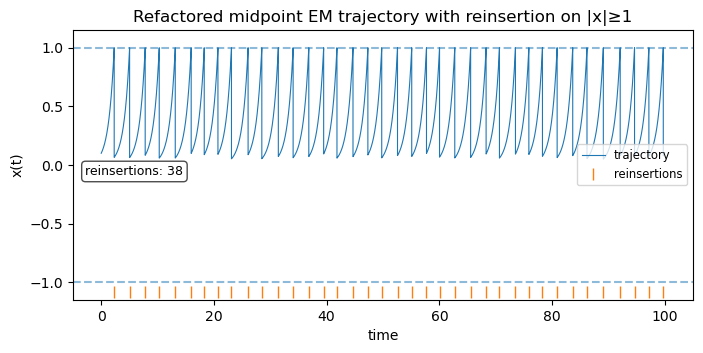

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_trajectory_with_reinsertions(ax, times, states, reset_times_per_path[0])

## Apply stochastic inertia tools

In [6]:
rng = np.random.default_rng(12345)
sigmas = np.linspace(0.0, 0.5, 101, dtype=np.float32)

times, states, sigma_arr = simulate_trajectories_per_sigma(
    # single sigma -> single column
    sigmas=sigmas,
    dt=1e-3,
    n_steps=10000000 - 1,
    reset_sampler=uniform_reset_sampler_vectorized,
    rng=rng,
    save_every=1,   # only keep every 10th step
    x0=0.1,
    dtype=np.float32
)
reset_times_per_path = [
    times[np.abs(states[:, j]) > 1] for j in range(states.shape[1])]

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Sequence


def plot_multiple_sigmas(times: np.ndarray,
                         states: np.ndarray,
                         sigmas: Sequence[float],
                         reset_times_per_path: Sequence[np.ndarray],
                         n_cols: int = 1,
                         figsize: tuple = (8, 3),
                         sharex: bool = True):
    """
    Create subplots showing trajectories for multiple sigma values.

    Parameters
    ----------
    times : np.ndarray
        Common time vector returned by simulate_over_sigmas.
    results_dict : dict
        Dictionary mapping sigma -> {'states', 'jump_times', 'jump_states'}.
    sigmas : Sequence[float]
        Array/list of sigma values to plot (must be keys of results_dict).
    n_cols : int, optional
        Number of subplot columns. Rows are computed automatically.
    figsize : tuple, optional
        Base figure size per row.
    sharex : bool, optional
        Whether to share x-axis among subplots.
    """
    n_sigmas = len(sigmas)
    n_rows = int(np.ceil(n_sigmas / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize[0] * n_cols,
                                      figsize[1] * n_rows),
                             sharex=sharex)
    axes = np.atleast_1d(axes).flatten()

    for i, sigma in enumerate(sigmas):
        ax = axes[i]
        data = states[:, i]
        plot_trajectory_with_reinsertions(
            ax=ax,
            times=times,
            states=data,
            jump_times=reset_times_per_path[i],
            title=f"σ = {sigma:.3f}",
            show_xlabel=(i >= (n_rows - 1) * n_cols),
            show_ylabel=(i % n_cols == 0)
        )

    # Hide any unused axes (if n_sigmas < n_rows * n_cols)
    for j in range(n_sigmas, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

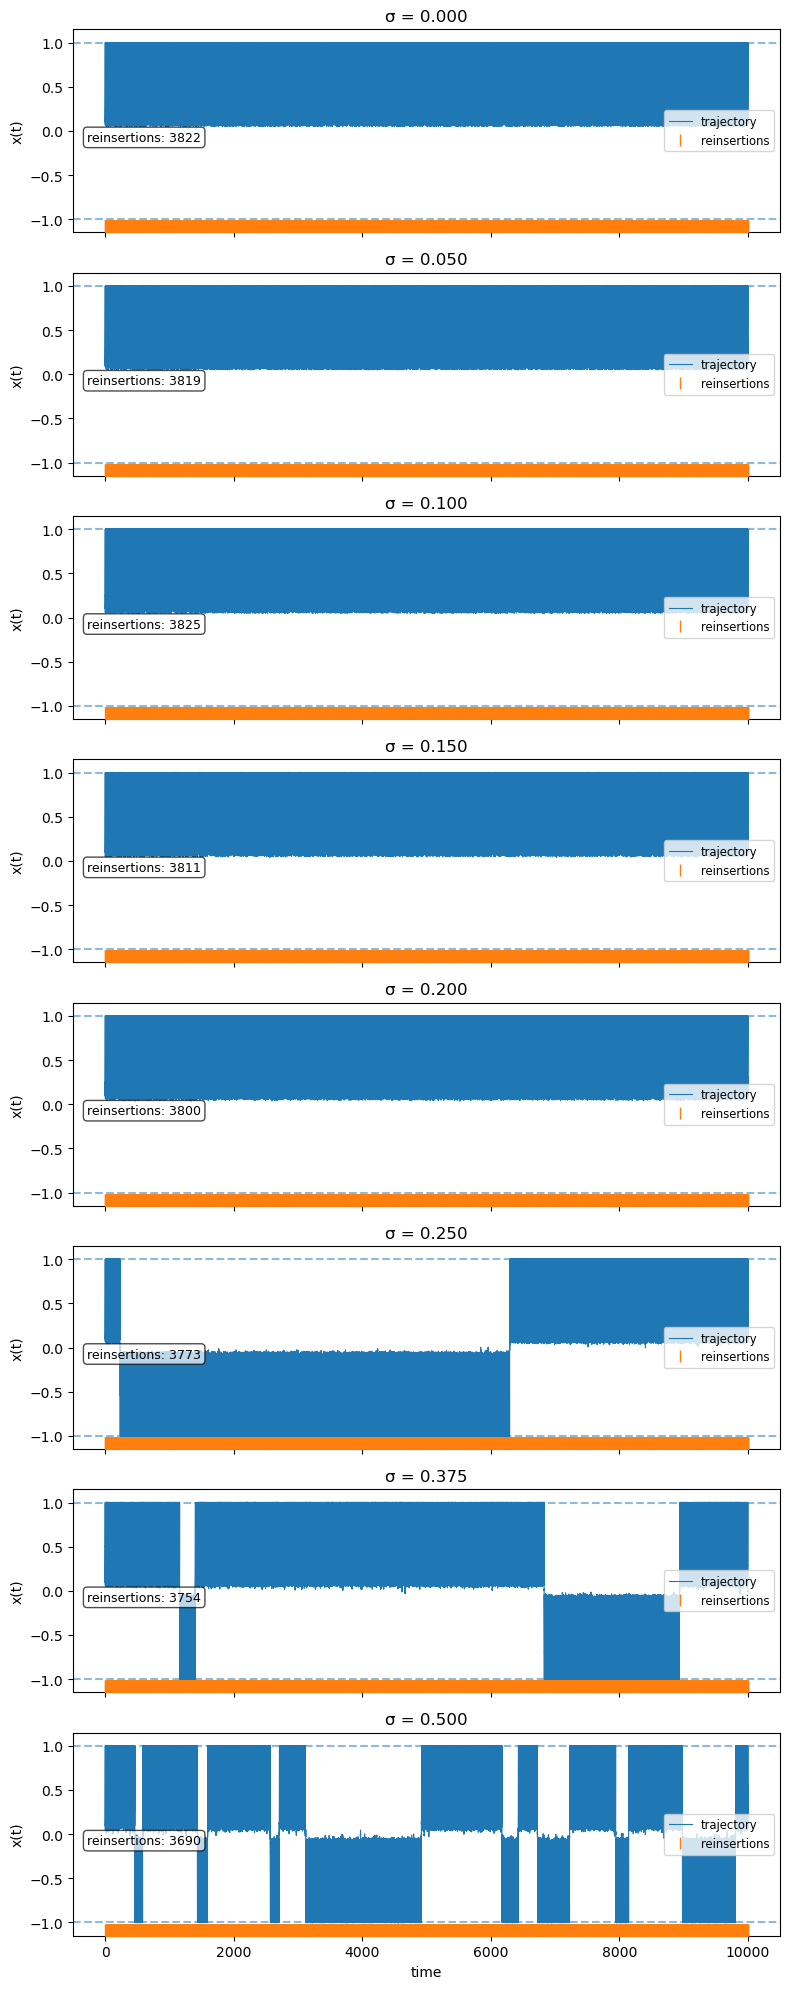

In [8]:
# import pickle
# with open("toy_simulation_data.pkl", "rb") as f:
#     times, data = pickle.load(f)

plot_multiple_sigmas(times, states,
                     np.quantile(sorted(sigma_arr),
                                 [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1]),
                     n_cols=1, figsize=(8, 2.5), reset_times_per_path=reset_times_per_path)

In [9]:
def compute_lifetimes_per_sigma(reset_times_per_path, sigma_arr):
    """
    Compute lifetimes (time intervals between resets) for each sigma value.

    Parameters
    ----------
    reset_times_per_path : list of 1D np.ndarrays
        Each array contains the times where |x| > 1 for a trajectory.
    sigma_arr : 1D np.ndarray
        Sigma value for each trajectory (same order as reset_times_per_path).

    Returns
    -------
    dict
        {sigma_value: [lifetimes...]} where each list holds float durations between resets.
    """
    return {
        sigma: np.diff(rt).tolist() if len(rt) >= 2 else []
        for sigma, rt in zip(sigma_arr, reset_times_per_path)
    }

In [10]:
lifetimes = compute_lifetimes_per_sigma(reset_times_per_path, sigma_arr)

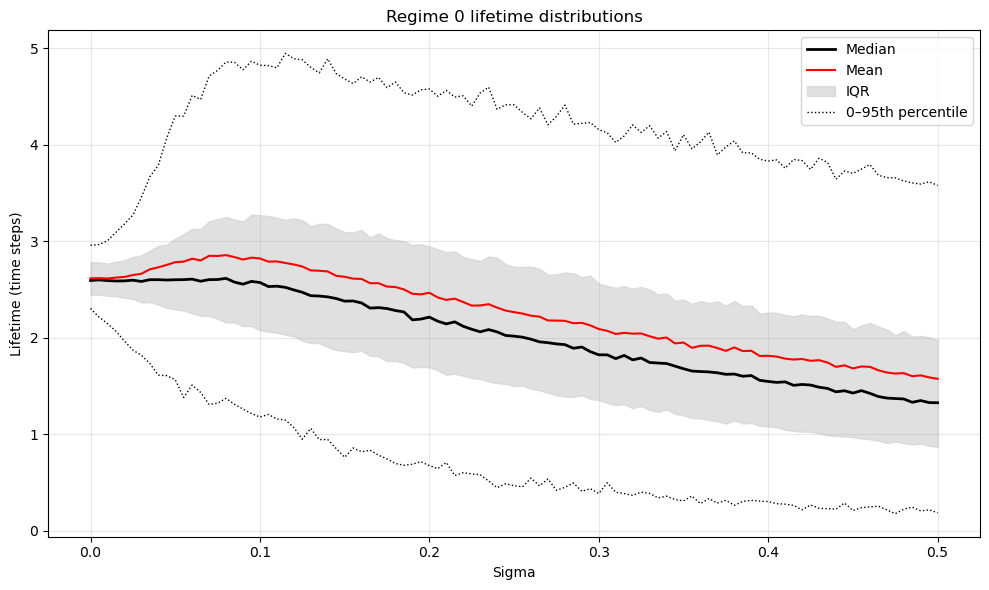

In [11]:
fig, ax = plot_lifetime_distributions_lines(
    {0: lifetimes}, regime=0, logx=False)

## Now the TO methods

In [12]:
rng = np.random.default_rng(12345)
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),   # single sigma -> single column
    dt=1e-3,
    n_steps=100000 - 1,
    reset_sampler=uniform_reset_sampler_vectorized,
    rng=rng,
    save_every=1,   # only keep every 10th step
    x0=0.1,
    dtype=np.float32
)
reset_times_per_path = [
    times[np.abs(states[:, j]) > 1] for j in range(states.shape[1])]

In [13]:
import numpy as np
from scipy import sparse


def diffusion_maps_matrix_1d(X, epsilon):
    """
    1D-specialized version of diffusion_maps_matrix.
    X: ndarray of shape (n_samples,) or (n_samples, 1)
    epsilon: float > 0
    Returns: (DMM, A) as scipy.sparse.csr_matrices (row-stochastic DMM, affinity A)
    """
    # flatten / validate 1D input
    X_arr = np.asarray(X)
    if X_arr.ndim == 2 and X_arr.shape[1] == 1:
        X_flat = X_arr.ravel()
    elif X_arr.ndim == 1:
        X_flat = X_arr
    else:
        raise ValueError(
            "diffusion_maps_matrix_1d expects 1D input (shape (n,) or (n,1)).")

    n_samples = X_flat.shape[0]
    if n_samples == 0:
        # empty inputs
        A = sparse.csr_matrix((n_samples, n_samples))
        return A, A

    # radius from epsilon (same choice as your original)
    r = np.sqrt(5.0 * epsilon)

    # sort points and use searchsorted to get neighbor windows efficiently
    order = np.argsort(X_flat)
    Xs = X_flat[order]   # sorted coordinates

    rows = []
    cols = []
    vals = []

    # For each sorted index, find neighbors in [x - r, x + r]
    for i_sorted, x in enumerate(Xs):
        left = np.searchsorted(Xs, x - r, side='left')
        right = np.searchsorted(Xs, x + r, side='right')
        if right <= left:
            # no neighbors found (shouldn't happen since self is within window), but guard
            continue
        idxs_sorted = np.arange(left, right)
        orig_rows = np.full(idxs_sorted.shape, order[i_sorted], dtype=np.int32)
        orig_cols = order[idxs_sorted].astype(np.int32)
        dists = np.abs(x - Xs[idxs_sorted]).astype(np.float64)

        rows.append(orig_rows)
        cols.append(orig_cols)
        vals.append(dists)

    # Concatenate lists
    rows = np.concatenate(rows).astype(np.int32)
    cols = np.concatenate(cols).astype(np.int32)
    vals = np.concatenate(vals).astype(np.float64)

    # Gaussian kernel: same convention as original: exp(-d^2 / epsilon)
    A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),
                          (rows, cols)), shape=(n_samples, n_samples)).tocsr()

    # Ensure self-loop weight (set diagonal to 1.0)
    A.setdiag(1.0)

    # density normalization (Coifman–Lafon style with alpha = 1.0)
    row_means = np.asarray(A.mean(axis=1)).ravel()
    row_means[row_means == 0] = np.finfo(float).eps
    q = 1.0 / row_means

    alpha = 1.0
    kalpha = q ** alpha
    D_k = sparse.diags(kalpha, offsets=0, format='csr')
    Adensnorm = D_k.dot(A).dot(D_k)

    # row-normalize to get Markov matrix DMM
    row_sums = np.asarray(Adensnorm.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = np.finfo(float).eps
    inv_row_sums = 1.0 / row_sums
    D_norm = sparse.diags(inv_row_sums, offsets=0, format='csr')
    DMM = D_norm.dot(Adensnorm)

    return DMM, A

In [23]:
import numpy as np
from scipy.sparse import eye
from scipy.sparse.linalg import spsolve, spilu, LinearOperator, bicgstab
from scipy.sparse import issparse


def expected_escape_times_from_TO_fast(L, mask,
                                       direct_cutoff=4000,
                                       ilu_drop_tol=1e-3,
                                       krylov_tol=1e-8,
                                       krylov_maxiter_factor=10,
                                       richardson_tol=1e-8,
                                       richardson_maxiter=5000):
    """
    Solve (I - Q) t = 1 where Q = L[indices, :][:, indices] and 'mask' selects the blocking set.

    Strategy:
      - If m <= direct_cutoff: use direct sparse solve (spsolve).
      - Else: try ILU preconditioner + bicgstab.
      - If ILU or bicgstab fails, fallback to simple Richardson iteration:
            t_{k+1} = 1 + Q t_k
        (equivalent to Neumann series) until convergence.

    Parameters:
      L : scipy.sparse matrix (transfer operator)
      mask : boolean array selecting the blocking indices (source nodes)
      direct_cutoff : int, size threshold below which a direct solve is used
      ilu_drop_tol : float, drop tolerance for spilu preconditioner
      krylov_tol : float, tolerance for bicgstab
      krylov_maxiter_factor : int, max iterations = factor * m
      richardson_tol : float, tolerance for Richardson residual
      richardson_maxiter : int, max Richardson iterations

    Returns:
      t_escape : 1D numpy array of length m (floats)
    """
    indices = np.nonzero(mask)[0]
    m = indices.size
    if m == 0:
        return np.array([], dtype=float)

    # Build Q in csr (note: L may be row- or column-stochastic depending on pipeline;
    # this matches your original usage of L[1:,:-1] indexing.)
    Q = L[indices, :][:, indices].tocsr()

    # build I - Q
    IminusQ = eye(m, format='csr') - Q

    # RHS vector
    b = np.ones(m, dtype=float)

    # 1) small problems: direct sparse solver
    if m <= direct_cutoff:
        t = spsolve(IminusQ, b)
        return t

    # 2) try ILU preconditioner + bicgstab
    # spilu requires csc matrix
    try:
        # convert to csc for spilu and compute ILU factorization
        ilu = spilu(IminusQ.tocsc(), drop_tol=ilu_drop_tol)
        # create preconditioner as LinearOperator
        M = LinearOperator((m, m), matvec=ilu.solve)

        maxiter = int(krylov_maxiter_factor * m)
        t, info = bicgstab(IminusQ, b, rtol=krylov_tol, maxiter=maxiter, M=M)
        if info == 0:
            return t
        else:
            # info > 0 means no convergence in maxiter; info < 0 means breakdown
            # proceed to fallback
            print(
                f"bicgstab did not converge (info={info}), falling back to Richardson.")
    except Exception as e:
        # ILU failed (memory/zero pivot etc) -> fallback
        print("ILU preconditioning failed or unavailable, falling back to Richardson. Exception:", e)

    # 3) fallback: Richardson / Neumann fixed-point iteration
    # iterate t_{k+1} = 1 + Q t_k, starting from t0 = 0
    # stop when ||residual||/||b|| < tol, where residual = (I-Q)t - 1
    t = np.zeros(m, dtype=float)
    bnorm = np.linalg.norm(b)
    if bnorm == 0:
        bnorm = 1.0
    for it in range(richardson_maxiter):
        t_new = b + Q.dot(t)
        # compute residual r = (I-Q) t_new - b = -Q(t_new - t)  -> easier compute r = t_new - Q.dot(t_new) - b
        r = t_new - Q.dot(t_new) - b
        res_norm = np.linalg.norm(r)
        if res_norm / bnorm <= richardson_tol:
            return t_new
        t = t_new
    # if still not converged, return last iterate with a warning
    print(
        f"Richardson did not converge in {richardson_maxiter} iterations; residual={res_norm:.3e}")
    return t

In [24]:
det_traj = states[:10000, 0].reshape(-1, 1)   # shape (N,1)

blocking_mask = np.abs(det_traj[:-1, 0]) < 1.0   # boolean array length N-1

t_escape_dict = {}

eps_values = (2*sigmas**2)[1:10]

In [26]:

for eps in eps_values:
    print(f"Processing epsilon = {eps:.6f}")

    # diffusion_maps_matrix should return a row-stochastic matrix DMM (NxN) and optional affinity A
    DMM, A = diffusion_maps_matrix_1d(det_traj, eps)
    print(f"DMM shape: {DMM.shape}, nnz: {DMM.nnz}")
    # build one-step transfer operator mapping states at time t -> t+dt
    # shape: (N-1, N-1)
    L = DMM[1:, :-1]

    # compute expected escape times starting from each "from-node" (length N-1)
    t_escape = expected_escape_times_from_TO_fast(L, blocking_mask)

    t_escape_dict[eps] = t_escape

Processing epsilon = 0.000050
DMM shape: (10000, 10000), nnz: 5391300
Processing epsilon = 0.000200
DMM shape: (10000, 10000), nnz: 10530542
Processing epsilon = 0.000450
DMM shape: (10000, 10000), nnz: 15333170
Processing epsilon = 0.000800
DMM shape: (10000, 10000), nnz: 19769801
Processing epsilon = 0.001250
DMM shape: (10000, 10000), nnz: 23893138
Processing epsilon = 0.001800
DMM shape: (10000, 10000), nnz: 27747658
Processing epsilon = 0.002450
DMM shape: (10000, 10000), nnz: 31368236
Processing epsilon = 0.003200
DMM shape: (10000, 10000), nnz: 34782548
Processing epsilon = 0.004050
DMM shape: (10000, 10000), nnz: 38013180


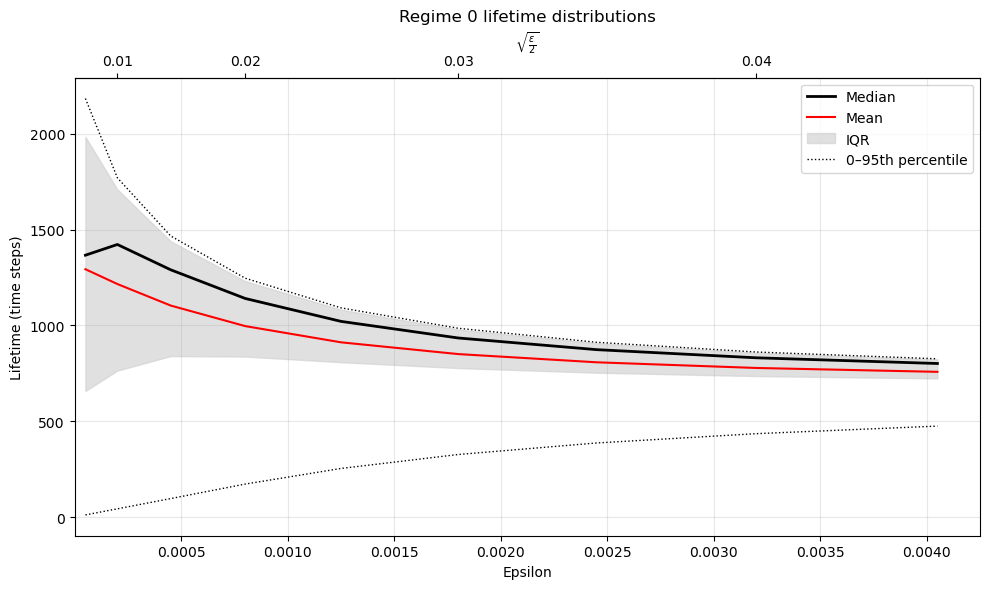

In [27]:
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

In [22]:
sigma_arr

array([0.], dtype=float32)

In [18]:
states.shape

(100000, 1)

In [17]:
reset_times_per_path[0].shape

(38,)

In [ ]:
states.shape

(10000000,)

In [ ]:
np.where(jump_times[0] == times)[0][0]

np.int64(2304)

In [ ]:
det_traj = states[:np.where(jump_times[0] == times)[0][0]].reshape(-1, 1)
block_mask = (np.abs(det_traj) >= 1.0)[1:]

In [ ]:
block_mask

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]], shape=(2304, 1))

In [ ]:
L

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 124851 stored elements and shape (2303, 2303)>

In [ ]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import eye
DMM, A = diffusion_maps_matrix(det_traj, eps)
L = DMM[1:, :-1]
L.shape
Q = L[:-1, :][:, :-1].tocsr()
I = eye(Q.shape[0], format='csr')
t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
p0 = np.zeros_like(block_mask, dtype=float)
p0[block_mask] = 1 / \
    (block_mask).sum()
print(f"shape p0: {p0.shape}, sum p0: {p0.sum()}, shape L: {L.shape}")
p1 = p0.T @ L
p_regime = p1[not (block_mask.T)]
p_enter = p_regime / p_regime.sum()
t_escape_dict[eps] = np.dot(p_enter, t_escape)

shape p0: (2303, 1), sum p0: 1.0, shape L: (2303, 2303)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
p1[(block_mask == False).T]

array([0.        , 0.        , 0.        , ..., 0.04669165, 0.0973995 ,
       0.17383181], shape=(2302,))

In [ ]:
block_mask.T.shape

(1, 2303)

In [ ]:
p1

array([[0.        , 0.        , 0.        , ..., 0.0973995 , 0.17383181,
        0.2720529 ]], shape=(1, 2303))

In [ ]:
t_escape_dict = {}

for eps in np.linspace(0, 0.005, 501)[1:]:
    DMM, A = diffusion_maps_matrix(det_traj, eps)
    L = DMM[1:, :-1]
    L.shape
    Q = L[:-1, :][:, :-1].tocsr()
    from scipy.sparse import eye
    from scipy.sparse.linalg import spsolve
    from scipy.sparse import csr_matrix
    I = eye(Q.shape[0], format='csr')
    t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
    p0 = np.zeros_like(block_mask, dtype=float)
    p0[block_mask] = 1 / \
        (block_mask).sum()
    p1 = p0.T @ L
    p_regime = p1[(block_mask == False).T]
    p_enter = p_regime / p_regime.sum()
    t_escape_dict[eps] = np.dot(p_enter, t_escape)

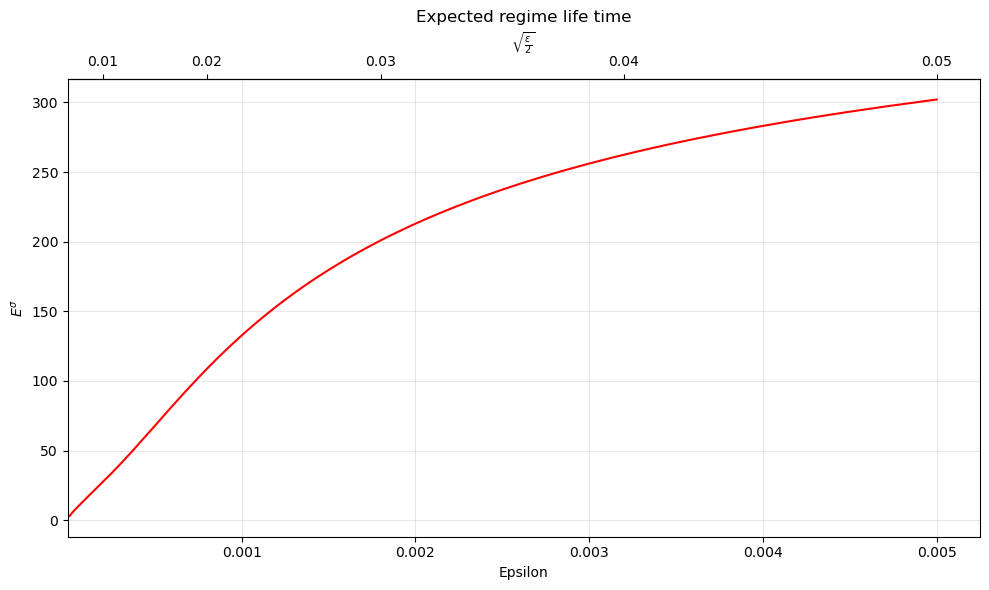

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.linspace(0, 0.005, 501)[1:501],
        np.array([t_escape_dict[k]
                 for k in sorted(t_escape_dict.keys())]),
        color='red', linewidth=1.5)
ax.set_xlabel("Epsilon")
ax.set_ylabel("$E^{\\sigma}$")
ax.set_title("Expected regime life time")
ax.grid(True, alpha=0.3)

fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))
plt.tight_layout()

In [ ]:
t_escape

array([1888.77672817, 1888.76539513, 1888.75458121, ...,   12.41725153,
         11.84252021,   11.29969133], shape=(2302,))

In [ ]:
t_escape_dict = {}

for eps in np.linspace(0, 0.005, 501)[1:10]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = DMM[1:, :-1]

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(
        L, (np.abs(det_traj) >= 1.0))  # [:-1])

    # Store
    t_escape_dict[eps] = t_escape

Processing epsilon = 0.000010
Processing epsilon = 0.000020
Processing epsilon = 0.000030
Processing epsilon = 0.000040
Processing epsilon = 0.000050
Processing epsilon = 0.000060
Processing epsilon = 0.000070
Processing epsilon = 0.000080
Processing epsilon = 0.000090


In [ ]:
t_escape_dict

{np.float64(0.001): array([1074.48053359, 1074.47733018, 1074.47380361, ...,  122.67473166,
         122.02375652,  121.38032256], shape=(2302,)),
 np.float64(0.002): array([812.51019863, 812.5076652 , 812.50537384, ..., 200.70211657,
        200.16483583, 199.63134915], shape=(2302,)),
 np.float64(0.003): array([692.89176793, 692.88989512, 692.8880158 , ..., 243.78365488,
        243.34241284, 242.9101526 ], shape=(2302,)),
 np.float64(0.004): array([626.01414177, 626.01229573, 626.01066092, ..., 271.21020845,
        270.84876288, 270.48880533], shape=(2302,)),
 np.float64(0.005): array([584.04992989, 584.04825931, 584.04679146, ..., 290.60128974,
        290.2925228 , 289.98480924], shape=(2302,)),
 np.float64(0.006): array([555.72703378, 555.72569382, 555.72414822, ..., 305.32348837,
        305.05405663, 304.78540698], shape=(2302,)),
 np.float64(0.007): array([535.65092036, 535.64947925, 535.64823104, ..., 317.09780096,
        316.85874074, 316.62028179], shape=(2302,)),
 np.flo

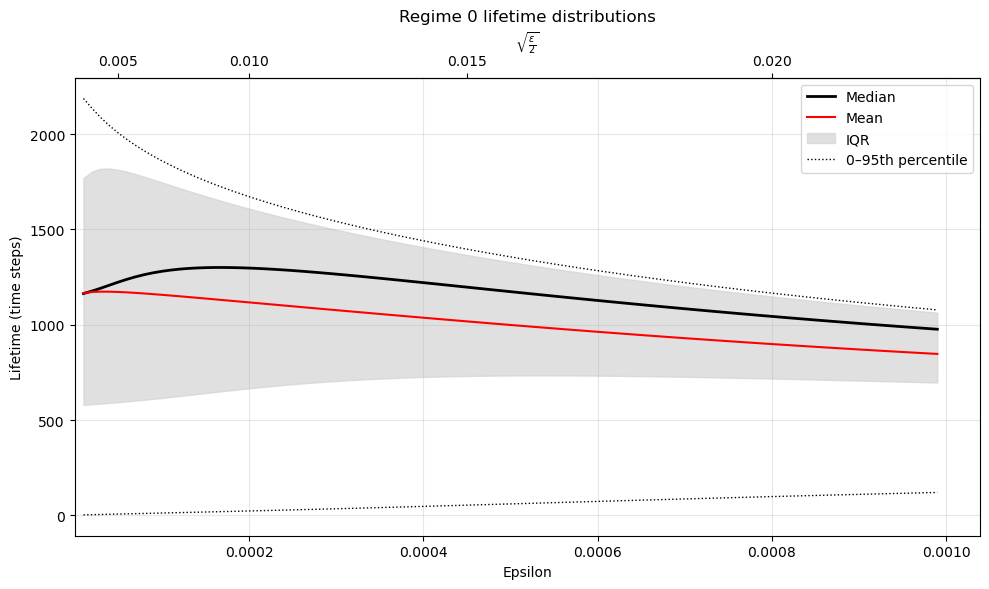

In [ ]:
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

In [ ]:
# deterministic trajectory
det_traj = states.reshape(-1, 1)
t_escape_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:10]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = DMM[1:, :-1]

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(L, det_traj)

    # Store
    t_escape_dict[eps] = t_escape

fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

Processing epsilon = 0.000010


: 

In [ ]:
regime_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = DMM[1:, :-1]

    # Compute expected escape times for the blocking set
    t_escape = t_escape_dict[eps]
    p0 = np.zeros(len(det_traj))
    p0[det_traj == 0] = 1 / (det_traj == 0).sum()
    p1 = p0 @ L
    p_regime = p1[det_traj == 1]
    p_enter = p_regime / p_regime.sum()
    regime_dict[eps] = np.dot(p_enter, t_escape)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.array(sorted(regime_dict.keys())),
        np.array([regime_dict[k]
                 for k in sorted(regime_dict.keys())]),
        color='red', linewidth=1.5)
ax.set_xlabel("Epsilon")
ax.set_ylabel("$E^{\\sigma}$")
ax.set_title("Expected regime life time")
ax.grid(True, alpha=0.3)

fig, ax = add_scaled_top_axis(fig, ax, sorted(regime_dict.keys()))
plt.tight_layout()

In [ ]:
escape_rate_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator and transpose
    L = DMM[1:, :-1]

    Q = L[det_cluster_res["labels"] == 1, :][:, det_cluster_res["labels"] == 1]
    eigval, _ = eigs(Q, k=1, which='LM')
    # Store
    escape_rate_dict[eps] = eigval.real[0]

# Legacy

In [ ]:
import numpy as np
from typing import Callable, Optional, Tuple

ResetSampler = Callable[[np.random.Generator], float]


def dxdt(x: float) -> float:
    return x


def midpoint_step(x: float,
                  dt: float,
                  sigma: float,
                  rng: np.random.Generator,
                  reset_sampler: ResetSampler) -> Tuple[float, bool]:
    """
    One midpoint-style step (deterministic RK2 on drift + additive noise).
    Returns (x_new, jumped) where jumped is True if reinsertion occurred.
    """
    if abs(x) >= 1.0:
        X_new = np.sign(x)*reset_sampler(rng)
        return float(X_new), True
    dW = rng.normal(loc=0.0, scale=np.sqrt(dt))
    k1 = dt * dxdt(x)
    k2 = dt * dxdt(x + 0.5 * k1)
    x_new = x + k2 + sigma * dW

    return float(x_new), False


def integrate_midpoint(dt: float,
                       save_interval: float,
                       sigma: float,
                       n_steps: int,
                       x0: float,
                       reset_sampler: ResetSampler,
                       rng: np.random.Generator
                       ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Integrate using the refactored midpoint scheme up to n_steps and also
    return reinsertion times and post-reinsertion states.

    Returns:
      times, states, jump_times, jump_states
    where jump_times/jump_states are 1D numpy arrays (possibly empty).
    """

    if save_interval <= 0 or save_interval < dt:
        save_every = 1
    else:
        save_every = max(1, int(round(save_interval / dt)))

    max_saves = (n_steps // save_every) + 1
    times = np.empty(max_saves, dtype=float)
    states = np.empty(max_saves, dtype=float)

    jump_times = []

    x = float(x0)
    t = 0.0
    save_idx = 0

    # Save initial state
    times[save_idx] = t
    states[save_idx] = x
    save_idx += 1

    for step in range(1, n_steps + 1):
        x, jumped = midpoint_step(x, dt, sigma, rng, reset_sampler)
        t += dt

        if jumped:
            jump_times.append(t)

        if (step % save_every) == 0:
            times[save_idx] = t
            states[save_idx] = x
            save_idx += 1

    # Trim arrays
    times = times[:save_idx]
    states = states[:save_idx]
    jump_times = np.array(jump_times, dtype=float)

    return times, states, jump_times


# ---- Example reset samplers ----
def uniform_reset_sampler(rng: np.random.Generator) -> float:
    """Uniform reinsertion on [-1,1]."""
    return rng.uniform(0.05, 0.1)


def beta_symmetric_reset_sampler(rng: np.random.Generator, a: float = 2.0, b: float = 2.0) -> float:
    """Symmetric Beta reinsertion on [-1,1]."""
    u = rng.beta(a, b)
    sign = -1.0 if rng.random() < 0.5 else 1.0
    return sign * u

In [ ]:
# DROP-IN replacement for `integrate_midpoint` (paste this cell)
import math
import numpy as np
from numba import njit
from typing import Callable, Optional, Tuple

ResetSampler = Callable[[np.random.Generator], float]


@njit(cache=True)
def _integrate_midpoint_numba(dt: float,
                              sigma: float,
                              n_steps: int,
                              save_every: int,
                              x0: float,
                              dW: np.ndarray,
                              reset_samples: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Numba hot-loop. Returns (times, states, jump_times).
    Behavior matches your Python version: if |x|>=1 at start of step, reset to sign(x)*reset_sample.
    """
    max_saves = (n_steps // save_every) + 1
    times = np.empty(max_saves, dtype=np.float64)
    states = np.empty(max_saves, dtype=np.float64)

    jump_times = np.empty(n_steps, dtype=np.float64)  # will trim
    jump_idx = 0
    reset_idx = 0

    x = float(x0)
    t = 0.0
    save_idx = 0

    # Save initial state
    times[save_idx] = t
    states[save_idx] = x
    save_idx += 1

    for i in range(n_steps):
        # reset if outside at start of step (preserve sign)
        if x >= 1.0 or x <= -1.0:
            sign = 1.0 if x >= 0.0 else -1.0
            x = sign * reset_samples[reset_idx]
            reset_idx += 1
            jumped = True
        else:
            # midpoint RK2 for dxdt(x) = x
            k1 = dt * x
            k2 = dt * (x + 0.5 * k1)
            x = x + k2 + sigma * dW[i]
            jumped = False

        # Advance time (same ordering as your Python)
        t += dt

        if jumped:
            jump_times[jump_idx] = t
            jump_idx += 1

        if ((i + 1) % save_every) == 0:
            times[save_idx] = t
            states[save_idx] = x
            save_idx += 1

    # trim arrays
    times = times[:save_idx].copy()
    states = states[:save_idx].copy()
    jump_times = jump_times[:jump_idx].copy()

    return times, states, jump_times


def integrate_midpoint(dt: float,
                       save_interval: float,
                       sigma: float,
                       n_steps: int,
                       x0: float,
                       reset_sampler: ResetSampler,
                       rng: np.random.Generator
                       ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Drop-in replacement that uses a Numba inner loop.
    Signature and return values match your original function:
      returns (times, states, jump_times)
    """
    if save_interval <= 0 or save_interval < dt:
        save_every = 1
    else:
        save_every = max(1, int(round(save_interval / dt)))

    # Precompute increments and reset samples in Python (keeps RNG use identical to before)
    sqrt_dt = math.sqrt(dt)
    dW = rng.normal(loc=0.0, scale=sqrt_dt, size=n_steps).astype(np.float64)

    reset_samples = np.empty(n_steps, dtype=np.float64)
    for i in range(n_steps):
        # reset_sampler uses the same rng you pass in
        reset_samples[i] = reset_sampler(rng)

    # Call the compiled integrator
    times, states, jump_times = _integrate_midpoint_numba(
        float(dt),
        float(sigma),
        int(n_steps),
        int(save_every),
        float(x0),
        dW,
        reset_samples
    )

    return times, states, jump_times

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# parameters
dt = 1e-3
save_interval = 1e-3   # save every 2 time units
sigma = 0
n_steps = 1000000 - 1
x0 = 0.1
rng = np.random.default_rng(42)

# run the integrator from Cell 1
times, states, jump_times = integrate_midpoint(
    dt=dt,
    save_interval=save_interval,
    sigma=sigma,
    n_steps=n_steps,
    x0=x0,
    reset_sampler=uniform_reset_sampler,
    rng=rng
)

In [ ]:
from typing import Callable, Optional, Dict, Any, Tuple


def simulate_over_sigmas(sigmas: np.ndarray,
                         dt: float,
                         save_interval: float,
                         n_steps: int,
                         x0: float,
                         reset_sampler: Callable[[np.random.Generator], float],
                         rng_seed: Optional[int] = None
                         ) -> Tuple[np.ndarray, Dict[float, Dict[str, np.ndarray]]]:
    """
    Run integrate_midpoint for each sigma in `sigmas` and return:
      times, results_dict

    - `times` is the common time vector returned by integrate_midpoint.
    - `results_dict` maps each sigma (float) -> {'states': np.ndarray, 'jump_times': np.ndarray, 'jump_states': np.ndarray}

    Requirements:
      - `integrate_midpoint(dt, save_interval, sigma, n_steps, x0, reset_sampler, rng)`
        must be defined in the namespace and return (times, states, jump_times, jump_states).
    Reproducibility:
      - If rng_seed is not None, each sigma run uses seed = rng_seed + i (i = index).
    """
    sigmas = np.asarray(sigmas, dtype=float)
    results: Dict[float, Dict[str, np.ndarray]] = {}
    common_times: Optional[np.ndarray] = None

    for i, sigma in enumerate(sigmas):
        seed = None if rng_seed is None else int(rng_seed) + i
        rng = np.random.default_rng(seed)

        # integrate_midpoint is expected to return (times, states, jump_times)
        t_vec, states, jump_times = integrate_midpoint(
            dt=dt,
            save_interval=save_interval,
            sigma=float(sigma),
            n_steps=n_steps,
            x0=x0,
            reset_sampler=reset_sampler,
            rng=rng
        )

        # set/validate common times
        if common_times is None:
            common_times = t_vec

        # store results for this sigma
        results[float(sigma)] = {
            'states': np.asarray(states, dtype=float),
            'jump_times': np.asarray(jump_times, dtype=float)}

    if common_times is None:
        # no sigmas provided
        common_times = np.empty(0, dtype=float)

    return common_times, results

In [ ]:
import pickle
times, data = simulate_over_sigmas(
    sigmas=np.linspace(0.0, 0.1, 101),
    dt=dt,
    save_interval=save_interval,
    n_steps=n_steps,
    x0=x0,
    reset_sampler=uniform_reset_sampler,
    rng_seed=42
)

0.0
0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.01
0.011
0.012
0.013000000000000001
0.014
0.015
0.016
0.017
0.018000000000000002
0.019
0.02
0.021
0.022
0.023
0.024
0.025
0.026000000000000002
0.027
0.028
0.029
0.03
0.031
0.032
0.033
0.034
0.035
0.036000000000000004
0.037
0.038
0.039
0.04
0.041
0.042
0.043000000000000003
0.044
0.045
0.046
0.047
0.048
0.049
0.05
0.051000000000000004
0.052000000000000005
0.053
0.054
0.055
0.056
0.057
0.058
0.059000000000000004
0.06
0.061
0.062
0.063
0.064
0.065
0.066
0.067
0.068
0.069
0.07
0.07100000000000001
0.07200000000000001
0.073
0.074
0.075
0.076
0.077
0.078
0.079
0.08
0.081
0.082
0.083
0.084
0.085
0.08600000000000001
0.08700000000000001
0.088
0.089
0.09
0.091
0.092
0.093
0.094
0.095
0.096
0.097
0.098
0.099
0.1


In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
import os


def _worker_call_integrate(args):
    sigma, dt, save_interval, n_steps, x0, reset_sampler, seed = args
    rng = np.random.default_rng(seed)
    t_vec, states, jump_times = integrate_midpoint(
        dt, save_interval, float(sigma), n_steps, x0, reset_sampler, rng
    )
    return float(sigma), t_vec, {
        "states": states,
        "jump_times": jump_times
    }


def simulate_over_sigmas_parallel(sigmas, dt, save_interval, n_steps, x0,
                                  reset_sampler, rng_seed=None, max_workers=None):
    sigmas = np.asarray(sigmas, dtype=float)
    if max_workers is None:
        max_workers = min(len(sigmas), os.cpu_count() - 1 or 1)
    args = []
    for i, sigma in enumerate(sigmas):
        seed = None if rng_seed is None else int(rng_seed) + i
        args.append((sigma, dt, save_interval,
                    n_steps, x0, reset_sampler, seed))
    results = {}
    common_times = None
    with ProcessPoolExecutor(max_workers=max_workers) as exe:
        futures = [exe.submit(_worker_call_integrate, a) for a in args]
        for fut in as_completed(futures):
            sigma_val, t_vec, data = fut.result()
            if common_times is None:
                common_times = t_vec
            results[float(sigma_val)] = data
    if common_times is None:
        common_times = np.empty(0, dtype=float)
    return common_times, results

In [ ]:
times, results = simulate_over_sigmas_parallel(
    sigmas=np.linspace(0.0, 0.1, 101),
    dt=dt,
    save_interval=save_interval,
    n_steps=n_steps,
    x0=x0,
    reset_sampler=uniform_reset_sampler
)

In [ ]:

with open("toy_simulation_data.pkl", "wb") as f:
    pickle.dump((times, data), f)

In [ ]:
def compute_escape_times_from_results(times, results):
    """
    Return dict mapping each sigma to its list of escape times 
    (intervals between reinsertion events).
    """
    return {s: np.diff(np.insert(d['jump_times'], 0, 0.0)).tolist() for s, d in results.items()}

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Regime 0 lifetime distributions'}, xlabel='Sigma', ylabel='Lifetime (time steps)'>)

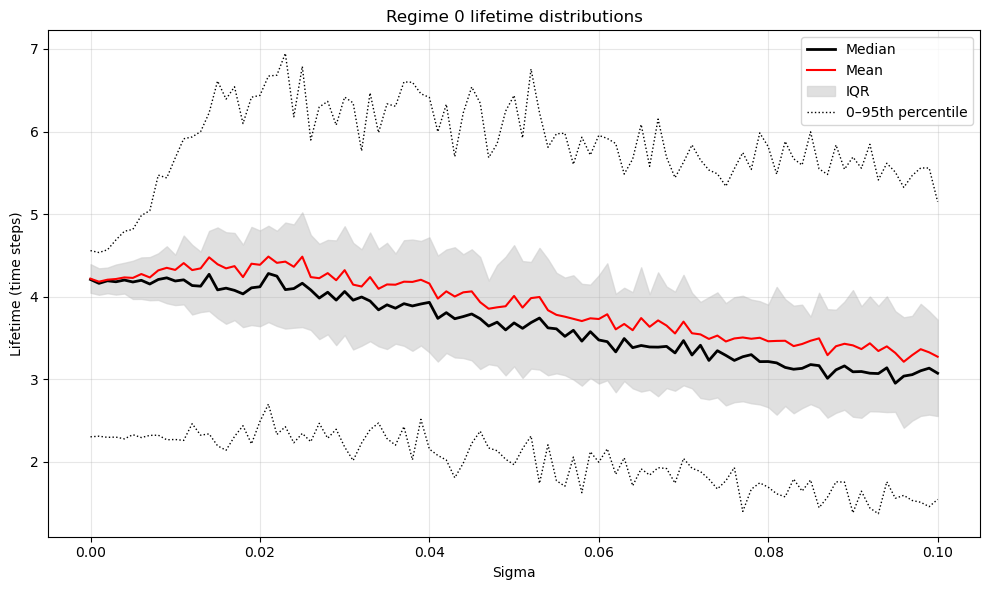

In [ ]:
escape_times = compute_escape_times_from_results(times, states)


plot_lifetime_distributions_lines(
    {0: escape_times}, regime=0, logx=False)